### Load the water_potability dataset from kaggle, explore missing values and outliers

1. Load the dataset and keep only the 80% test split for all exploration (random_state=42).

In [236]:
import os
import kagglehub
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

PATH = Path.cwd().parent
DATA_PATH = PATH / "data" / "raw"
os.makedirs(DATA_PATH, exist_ok=True)
dataset = "adityakadiwal/water-potability"
kagglehub.dataset_download(dataset, output_dir=str(DATA_PATH))
df = pd.read_csv(DATA_PATH / "water_potability.csv")

# Keep only the test partition for all subsequent analysis.
target = df["Potability"]
df, _ = train_test_split(df, test_size=0.2, random_state=42, stratify=target)
df = df.copy()

2) check which columns contain missing values and in which percentage

In [237]:
missing_cols = df.columns[df.isna().any()]
(df[missing_cols].isna().mean() * 100).sort_values(ascending=False)

Sulfate            23.854962
ph                 14.770992
Trihalomethanes     5.114504
dtype: float64

3. Plot the correlation matrix with the missing values indicators -> no linear correlation observed, suspecting MCAR

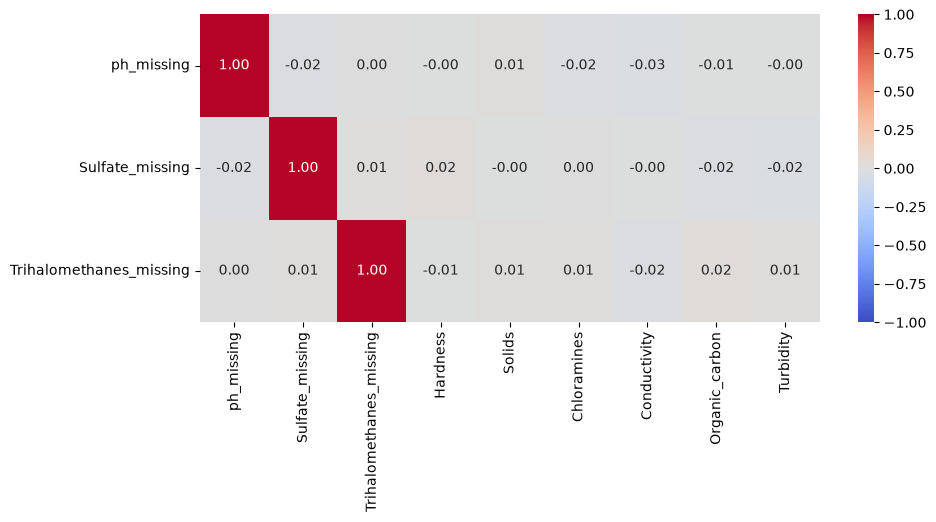

In [238]:
import matplotlib.pyplot as plt
import seaborn as sns

present_cols = [col for col in df.columns if col not in missing_cols]

for col in missing_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)

missing_indicators = [f"{col}_missing" for col in missing_cols]

corr_matrix = df[missing_indicators + present_cols[:-1]].corr(numeric_only=True)

plt.figure(figsize=(10, 4))

sns.heatmap(
    corr_matrix.loc[missing_indicators],
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.show()

4. plot the distributions to check for dependecies not caught by correlation -> no seeming dependencies

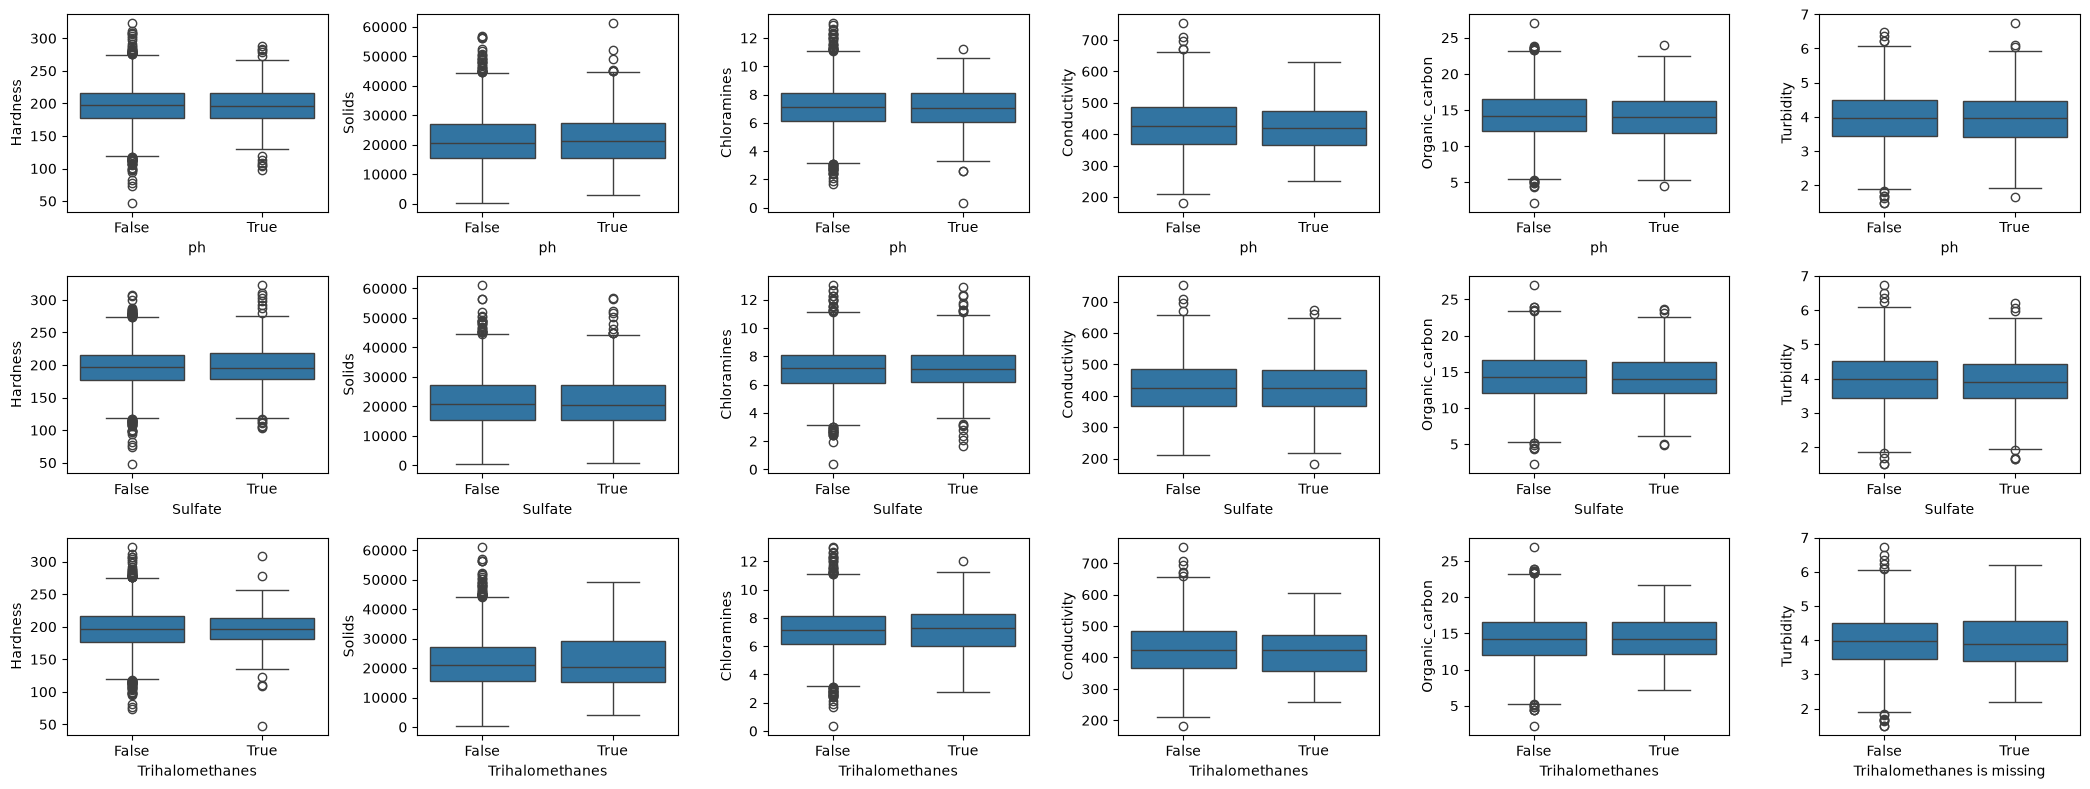

In [239]:
fig, axes = plt.subplots(3, 6, figsize=(21, 8))
for i in range(len(missing_cols)):
    for j in range(len(present_cols)-1):
        sns.boxplot(
            data=df,
            x=df[missing_cols[i]].isna(),
            y=present_cols[j],
            ax=axes[i][j]
        )
        plt.xlabel(f"{missing_cols[i]} is missing")

plt.tight_layout()
plt.show()

### Conclusion of missingness analysis

The missingness indicators have near-zero Pearson correlations with the observed variables. Visual comparison of the missing and non-missing groups also shows broadly similar centers, spreads, and distribution shapes. Thus, there is no strong descriptive evidence that missingness is associated with the observed variables.

5. check if the variables are skewed/contain a lot of outliers to decide the impution strategy -> **mean** impution fits: all columns have near zero skewness (very symmetric) and a small percent of outliers

ph
skeweness: 0.08305152276336553
outliers percentage: 1.57%

Sulfate
skeweness: -0.0467772122050721
outliers percentage: 1.70%

Trihalomethanes
skeweness: -0.07161657362574696
outliers percentage: 1.05%



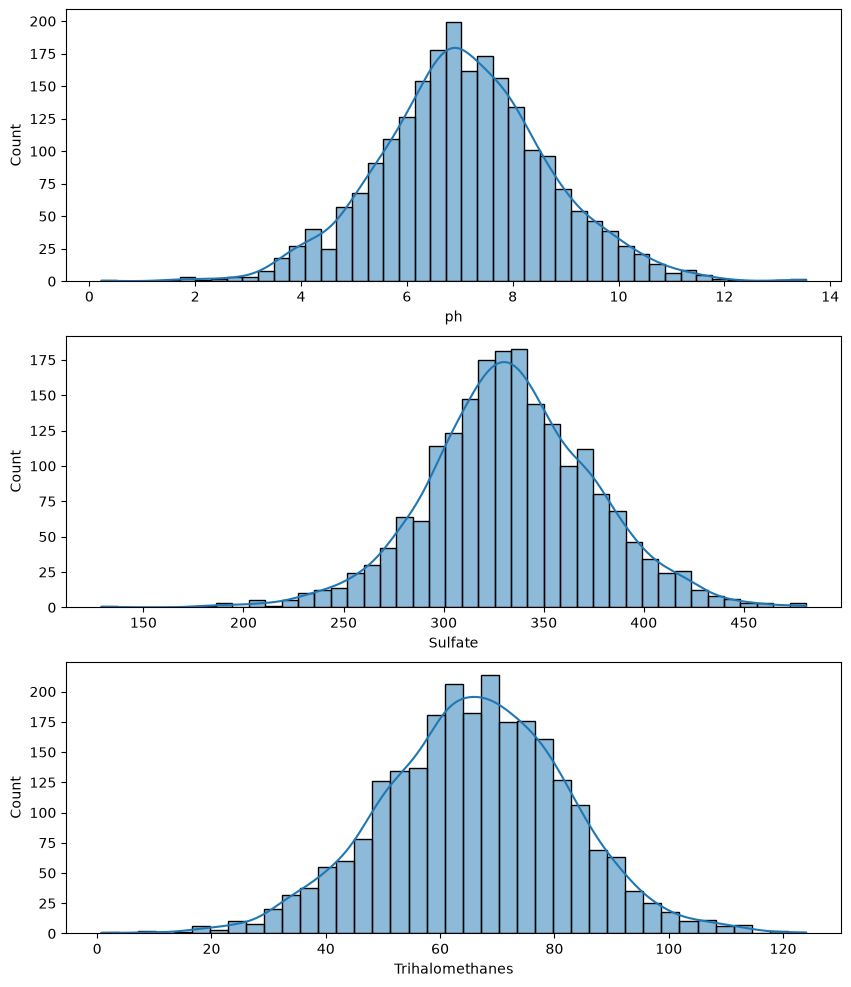

In [240]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
axes = axes.flatten()

for col in missing_cols:
    print(col)
    print(f"skeweness: {df[col].skew()}")
    x = df[col].dropna()

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    iqr = q3 - q1

    outliers = x[(x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)]
    percent = len(outliers) / len(x) * 100
    print(f"outliers percentage: {percent:.2f}%")
    print()

for col, ax in zip(missing_cols, axes):
    sns.histplot(df[col], kde=True, ax=ax)
plt.show()

In [255]:
df = df.drop(columns=[col for col in df.columns if "missing" in col])


def find_outliers(iqr_num):
    outlier_mask = pd.Series(False, index=df.index)

    outlier_stats = []

    for col in df.columns[:-1]:
        x = df[col].dropna()

        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - iqr_num * iqr
        upper = q3 + iqr_num * iqr

        outliers = x[(x < lower) | (x > upper)]

        outlier_mask |= (df[col] < lower) | (df[col] > upper)

        # Add one row to our future table
        outlier_stats.append({
            "Feature": col,
            "IQR accepted range": f"{lower:.2f} – {upper:.2f}",
            "Actual range": f"{x.min():.2f} – {x.max():.2f}",
            "Outlier %": len(outliers) / len(x) * 100
        })


    display(pd.DataFrame(outlier_stats))
    print(f"percent of outliers found by iqr: {outlier_mask.mean() * 100:.2f}%")
    print("new proportion of potability:", df[~outlier_mask]["Potability"].mean(), "old proportion:", df["Potability"].mean())

print("normal IQR outliers using 1.5 coefficient")    
find_outliers(1.5)
print()
print("extreme IQR outliers using 3 coefficient")  
find_outliers(3)

normal IQR outliers using 1.5 coefficient


,Feature,IQR accepted range,Actual range,Outlier %
0,ph,3.15 – 11.02,0.23 – 13.54,1.567398
1,Hardness,118.43 – 275.23,47.43 – 323.12,2.786260
2,Solids,-1956.42 – 44617.80,320.94 – 61227.20,1.374046
3,Chloramines,3.14 – 11.10,0.35 – 13.04,2.022901
4,Sulfate,229.80 – 438.26,129.00 – 481.03,1.704261
5,Conductivity,192.43 – 659.12,181.48 – 753.34,0.267176
6,Organic_carbon,5.32 – 23.27,2.20 – 27.01,0.763359
7,Trihalomethanes,23.03 – 109.64,0.74 – 124.00,1.045857
8,Turbidity,1.86 – 6.08,1.49 – 6.74,0.534351


percent of outliers found by iqr: 10.19%
new proportion of potability: 0.3833404164895878 old proportion: 0.3900763358778626

extreme IQR outliers using 3 coefficient


,Feature,IQR accepted range,Actual range,Outlier %
0,ph,0.20 – 13.97,0.23 – 13.54,0.000000
1,Hardness,59.63 – 334.03,47.43 – 323.12,0.038168
2,Solids,-19421.75 – 62083.13,320.94 – 61227.20,0.000000
3,Chloramines,0.15 – 14.08,0.35 – 13.04,0.000000
4,Sulfate,151.62 – 516.43,129.00 – 481.03,0.050125
5,Conductivity,17.43 – 834.12,181.48 – 753.34,0.000000
6,Organic_carbon,-1.41 – 30.01,2.20 – 27.01,0.000000
7,Trihalomethanes,-9.45 – 142.12,0.74 – 124.00,0.000000
8,Turbidity,0.27 – 7.66,1.49 – 6.74,0.000000


percent of outliers found by iqr: 0.08%
new proportion of potability: 0.38961038961038963 old proportion: 0.3900763358778626


The 1.5×IQR rule identified 10.19% of observations as containing at least one statistical outlier. However, domain analysis showed that the observed extreme values remain plausible water-quality measurements rather than clear data-entry or measurement errors. Since extreme water-quality measurements may contain useful information for predicting potability, removing all IQR-flagged observations could discard valid predictive information. For this reason, the IQR coefficient was increased from 1.5 to 3, so that only extreme statistical outliers are removed while less extreme but potentially valid water-quality observations are retained.